- Correlation matrix across Baggage_Delay_Min, Total_Delay_Min, Passenger_Count
- Variance analysis across Aircraft_Type, Status
- Statistical validation of the main hypothesis; interpret and note limitations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\asus\Python class\Intership\Airline_cleaned_dataset14.csv")

In [3]:
df.head()

,Flight_ID,Airline,Origin,Destination,Aircraft_Type,Terminal,Gate,Weather_Condition,Flight_Date,Month,...,Actual_Arrival,Delay_Reason,Year,Day,Departure_Time,Arrival_Time,Departure_Hour,Departure_Minute,Arrival_Hour,Arrival_Minute
0,FL100000,Akasa Air,CCU,BOM,B777,T3,G9,Rain,2025-02-09,2,...,2025-02-09 17:18:00,No Delay,2025,9,15:34:00,17:18:00,15.0,34.0,17.0,18.0
1,FL100001,Vistara,BOM,MAA,B777,T2,G18,Clear,2025-06-17,6,...,2025-06-17 13:38:00,No Delay,2025,17,09:15:00,13:38:00,9.0,15.0,13.0,38.0
2,FL100002,Qatar Airways,MAA,CCU,B787,T1,G43,Clear,2025-04-19,4,...,2025-04-19 13:54:00,No Delay,2025,19,10:26:00,13:54:00,10.0,26.0,13.0,54.0
3,FL100003,Akasa Air,HYD,DEL,B777,T2,G24,Clear,2025-10-08,10,...,2025-10-08 23:29:00,No Delay,2025,8,20:29:00,23:29:00,20.0,29.0,23.0,29.0
4,FL100004,SpiceJet,BLR,CCU,A321,T1,G27,Clear,2025-02-25,2,...,2025-02-26 01:17:00,Maintenance,2025,25,23:21:00,01:17:00,23.0,21.0,1.0,17.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flight_ID                     20000 non-null  object 
 1   Airline                       20000 non-null  object 
 2   Origin                        20000 non-null  object 
 3   Destination                   20000 non-null  object 
 4   Aircraft_Type                 20000 non-null  object 
 5   Terminal                      20000 non-null  object 
 6   Gate                          20000 non-null  object 
 7   Weather_Condition             20000 non-null  object 
 8   Flight_Date                   20000 non-null  object 
 9   Month                         20000 non-null  int64  
 10  Scheduled_Departure           20000 non-null  object 
 11  Scheduled_Arrival             20000 non-null  object 
 12  Status                        20000 non-null  object 
 13  G

In [5]:
cols = ["Baggage_Delay_Min", "Total_Delay_Min", "Passenger_Count"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print("Outliers:", len(outliers))
    print("-"*40)

Baggage_Delay_Min
Outliers: 997
----------------------------------------
Total_Delay_Min
Outliers: 3611
----------------------------------------
Passenger_Count
Outliers: 0
----------------------------------------


                   Baggage_Delay_Min  Total_Delay_Min  Passenger_Count
Baggage_Delay_Min           1.000000         0.527901          0.00241
Total_Delay_Min             0.527901         1.000000         -0.00165
Passenger_Count             0.002410        -0.001650          1.00000


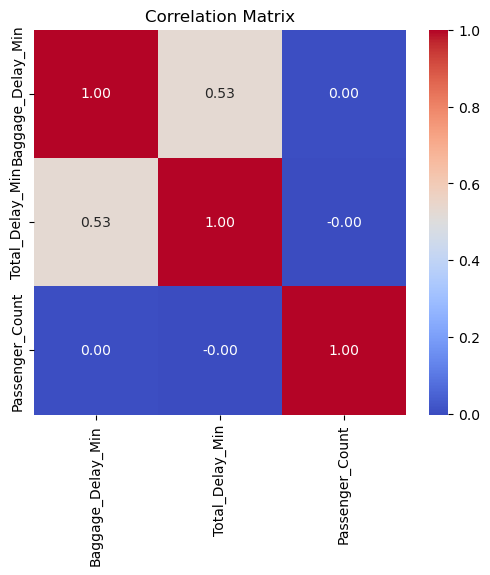

In [6]:
corr_cols = [
    "Baggage_Delay_Min",
    "Total_Delay_Min",
    "Passenger_Count"
]

corr = df[corr_cols].corr()

print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [9]:
variance_aircraft = df.groupby("Aircraft_Type")[
    ["Baggage_Delay_Min",
     "Total_Delay_Min",
     "Passenger_Count"]
].var()

print(variance_aircraft)

               Baggage_Delay_Min  Total_Delay_Min  Passenger_Count
Aircraft_Type                                                     
A320                         0.0              0.0      6161.289874
A321                         0.0              0.0      6265.344046
A350                         0.0              0.0      6158.685883
B737                         0.0              0.0      6078.713980
B777                         0.0              0.0      6049.951478
B787                         0.0              0.0      6264.234083


In [17]:
for col in delay_cols:
    print(col)
    print(df[col].value_counts().head(10))
    print("-"*40)

Gate_Delay_Min
Gate_Delay_Min
0     19034
10       58
11       54
9        45
7        44
21       42
13       41
8        41
28       40
22       40
Name: count, dtype: int64
----------------------------------------
Fuel_Delay_Min
Fuel_Delay_Min
0     19034
9        52
13       48
7        45
16       44
22       44
11       43
20       42
6        42
21       42
Name: count, dtype: int64
----------------------------------------
Baggage_Delay_Min
Baggage_Delay_Min
0    20000
Name: count, dtype: int64
----------------------------------------
Catering_Delay_Min
Catering_Delay_Min
0     18963
19       52
21       49
28       49
22       47
10       47
29       46
14       46
18       45
6        44
Name: count, dtype: int64
----------------------------------------
Passenger_Transfer_Delay_Min
Passenger_Transfer_Delay_Min
0     19016
21       49
23       49
9        46
22       46
28       45
15       43
25       42
13       42
7        41
Name: count, dtype: int64
-----------------------

In [18]:
df["Total_Delay_Min"] = (
    df["Gate_Delay_Min"]
    + df["Fuel_Delay_Min"]
    + df["Baggage_Delay_Min"]
    + df["Catering_Delay_Min"]
    + df["Passenger_Transfer_Delay_Min"]
)

In [19]:
print(df["Total_Delay_Min"].describe())
print(df["Total_Delay_Min"].value_counts().head(10))

count    20000.000000
mean         3.336150
std          9.918557
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        114.000000
Name: Total_Delay_Min, dtype: float64
Total_Delay_Min
0     17314
28      109
22      105
21      105
19       99
29       94
25       88
23       84
17       82
27       80
Name: count, dtype: int64


In [20]:
from scipy.stats import f_oneway

groups = [
    group["Total_Delay_Min"].dropna()
    for _, group in df.groupby("Aircraft_Type")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.7904812654103269
P-value: 0.5563021036936697


In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Aircraft_Type has a statistically significant effect on Total_Delay_Min")
else:
    print("Fail to Reject H0")
    print("No statistically significant difference between Aircraft_Type groups")

Fail to Reject H0
No statistically significant difference between Aircraft_Type groups


- Analysis is based only on the available sample.
- Missing values were imputed during preprocessing.
- Outliers may influence variance and correlation.
- Correlation does not imply causation.
- ANOVA assumes independence, approximate normality, and similar variances across groups; violations may affect the results.

In [23]:
df.to_csv("Airline_cleaned_dataset15.csv", index=False)